<p style="text-align:center">
    <img src="./assets/logo.png" width="200" alt="Aspada Logo">
</p>

# Hands-on With Basics of Machine Learning

This is a [Jupyter notebook](https://jupyter.org/). It allows you to share research and collaborate with others easily.

## Notebook Tour

Notebooks provide a compute environment where you can iteratively write, edit and run code and see the output.

Each notebook is made of a number of cells. Some cells are `markdown` cells like this one that do not contain executable code. And some cells like the one below are code cells

In [ ]:
print("Hello! This is a simple Python script.")

See how they look different? Click on the code cell and hit `shift` + `enter`. 

You will see the output appear under the cell.

That's it! We are ready to build some machine learning models.

## Set up the Environment

We have to load all the python libraries we need before we get started. Run the code blocks below to set up the environment.

In [ ]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3
!pip install seaborn==0.13.2
!pip install plotly

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
%matplotlib inline

## Simple Regression Model

We are going to build a simple regression model based on one feature.



### Load the data
The dataset you will use has been included with this project. You can use Pandas library to load the dataset.


In [ ]:
url= "./data/FuelConsumption.csv"
df=pd.read_csv(url)

In [ ]:
# verify successful load with some randomly selected records
df.sample(5)


### Understand the data

#### `FuelConsumption.csv`:
You will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2026
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Your task will be to create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature. 


### Explore the data
First, consider a statistical summary of the data.


In [ ]:
df.describe()

Let's pick some fields that we think might affect CO2 emissions.

In [ ]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(10)

#### Visualize features
Consider the histograms for each of these features.


In [ ]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

As you can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Go ahead and display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.


In [ ]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.


In [ ]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, you can see that their correlation is weaker than that for each of the three fuel consumption groups.


Let's look at the relationship between n umber of cylinders and C02 emissions

In [ ]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 Emission")
plt.show()

### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, you will use engine size to predict CO2 emission with a linear regression model.  
You can begin the process by extracting the input feature and target output variables, X and y, from the dataset.


In [ ]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, you will split the dataset into mutually exclusive training and testing sets. You will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, you want to randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller your data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that your evaluation of generalizability will have less reliability. Bigger is better when it comes to data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.


In [ ]:
type(X_train), np.shape(X_train), np.shape(X_test)

### Build a simple linear regression model

You'll use scikit-learn to build your model as follows. See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to learn all about the linear model predictor object.


 <b>Linear Function</b>
 
$$
Yhat = a + b  X
$$


In [ ]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Here, __Coefficient__ and __Intercept__ are the regression parameters determined by the model.  
They define the slope and intercept of the 'best-fit' line to the training data. 


### Visualize model outputs


You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.


In [ ]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

Let's add test data to the plot.

In [ ]:
plt.scatter(X_train, y_train,  color='blue')
plt.scatter(X_test, y_test,  color='orange')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [ ]:
# Plot first 10 y_pred and y_test against engine size to visualize the predictions vs actual values. 
# Connect each predicted point to the actual point with a line to see the error.
y_pred = regressor.predict(X_test.reshape(-1, 1))

plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r', label='Regression Line')
plt.scatter(X_test[:10], y_test[:10], color='orange', label='Actual')
plt.scatter(X_test[:10], y_pred[:10], color='blue', label='Predicted')
for i in range(10):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_pred[i]], color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.legend()
plt.show()

#### Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set: 
* **Mean Absolute Error**: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

* **Mean Squared Error (MSE)**: MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

* **Root Mean Squared Error (RMSE)**: RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

* **R2-Score**: It is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Test score: %.2f" % regressor.score(X_test.reshape(-1, 1), y_test))

### Use the model to predict emission

Let's use the model we create to predict the emission of a car with 6.5 engine size.

In [ ]:
# predict the emission of a car with 6.5 engine size
engine_size = 6.5
predicted_emission = regressor.predict(np.array([[engine_size]]))
print(f"Predicted CO2 emission for a car with {engine_size} engine size: {predicted_emission[0]:.2f} g/km")

### Bring your First-Bencher Energy
Rebuild the model with 80-20 test/train data split but use combined fuel consumption as the feature

---

## Multiple Linear Regression Model

Now that we have seen how to build a simple linear regression model and also its inability to model real-world problems, let's build a model with multiple features.

$$
Y: Response \ Variable\\\\\\
X_1 :Predictor\ Variable \ 1\\
X_2: Predictor\ Variable \ 2\\
X_3: Predictor\ Variable \ 3\\
X_4: Predictor\ Variable \ 4\\
$$

$$
a: intercept\\\\\\
b_1 :coefficients \ of\ Variable \ 1\\
b_2: coefficients \ of\ Variable \ 2\\
b_3: coefficients \ of\ Variable \ 3\\
b_4: coefficients \ of\ Variable \ 4\\
$$

The equation is given by

$$
Yhat = a + b_1 X_1 + b_2 X_2 + b_3 X_3 + b_4 X_4
$$

We have the original data loaded earlier stored in the variable `df`. We are going to use that to pick our features.

In [ ]:
df.head(10)

In [ ]:
cdf = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)
cdf.corr()

To make it easier to read, let's do a correlation matrix

In [ ]:
corr_matrix = cdf.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [ ]:
cdf = df[['ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]


In [ ]:
axes = pd.plotting.scatter_matrix(cdf, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

### Extract the input features and labels from the data set
Extract the required columns and convert the resulting dataframes to NumPy arrays.


In [ ]:
X = cdf.iloc[:,[0,1]].to_numpy()
y = cdf.iloc[:,[2]].to_numpy()

X[:10], y[:10]

### Preprocess selected features


You should standardize your input features so the model doesn't inadvertently favor any feature due to its magnitude.
The typical way to do this is to subtract the mean and divide by the standard deviation. Scikit-learn can do this for you.


In [ ]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)
# This is z = (x - u) / s, where u is the mean of the training samples and s is the standard deviation of the training samples.

In practice, if you want to properly evaluate your model, you should definitely not apply such operations to the entire dataset but to the train and test data separately. There's more to it than that. You'll dive deeper into this and other advanced evaluation pitfalls later in the course.


In [ ]:
pd.DataFrame(X_std).describe().round(2)

As you can see, a standardized variable has zero mean and a standard deviation of one.


### Create train and test datasets
Randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

### Build a multiple linear regression model
Multiple and simple linear regression models can be implemented with exactly the same scikit-learn tools.


In [ ]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)


The Coefficients and Intercept parameters define the best-fit hyperplane to the data. Since there are only two variables, hence two parameters, the hyperplane is a plane. But this best-fit plane will look different in the original, unstandardized feature space. 

You can transform your model's parameters back to the original space prior to standardization as follows. This gives you a proper sense of what they mean in terms of your original input features. Without these adjustments, the model's outputs would be tied to an abstract, transformed space that doesn’t align with the actual independent variables and the real-world problem you’re solving.


In [ ]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)


You would expect that for the limiting case of zero ENGINESIZE and zero FUELCONSUMPTION_COMB_MPG, the resulting CO2 emissions should also be zero. This is inconsistent with the 'best fit' hyperplane, which has a non-zero intercept of 329 g/km. The answer must be that the target variable does not have a very strong linear relationship to the dependent variables, and/or the data has outliers that are biasing the result. One or more of the variables might have a nonlinear relationship to the target. 


### Visualize model outputs
You can visualize the goodness-of-fit of the model to the training data by plotting the fitted plane over the data. 


In [ ]:
#from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Above Plane",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Below Plane",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUEL CONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()


Instead of making a 3D plot, which is difficult to interpret, you can look at vertical slices of the 3D plot by plotting each variable separately as a best-fit line using the corresponding regression parameters.


In [ ]:
plt.scatter(X_train[:,0], y_train,  color='blue')
# plt.scatter(X_test[:,0], y_test,  color='orange')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [ ]:
plt.scatter(X_train[:,1], y_train,  color='blue')
# plt.scatter(X_test[:,1], y_test,  color='orange')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()

Evidently, the solution is incredibly poor because the model is trying to fit a plane to a non-planar surface.


In [ ]:
# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Test score: %.2f" % regressor.score(X_test, y_test))

---

## Polynomial Regression Model


Let's try a polynomial model on this data.

<center><b>Quadratic - 2nd Order</b></center>

$$
Yhat = a + b_1 X +b_2 X^2 
$$




<center><b>Cubic - 3rd Order</b></center>

$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3\\\\\\
$$


<center><b>Higher-Order</b>:</center>

$$
Yhat = a + b_1 X +b_2 X^2 +b_3 X^3 ....\\
$$

In [ ]:
X_train[:10], y_train[:10]

In [ ]:
poly_regressor = np.polyfit(X_train[:,0], y_train.flatten(), 2)
polynomial = np.poly1d(poly_regressor)
print(polynomial)

In [ ]:
def PlotPolly(model, x1, y1, x2, y2, X_label, y_label):
    xmax=max([x1.max(), x2.max()])

    xmin=min([x1.min(), x2.min()])
    x_new = np.linspace(xmin, xmax,100)
    y_new = model(x_new)

    plt.plot(x1, y1, '.', x2, y2, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(X_label)
    plt.ylabel(y_label)
    plt.ylim([y1.min(), y1.max()])

    plt.show()
    plt.close()

In [ ]:
y_pred = polynomial(X_test[:,0])
PlotPolly(polynomial, X_train[:,0], y_train, X_test[:,0], y_test, 'Engine size', 'CO2 Emission')

In [ ]:
# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

### Simplify polynomial regression to linear regression

Turns out we can use linear regression instead of polynomial because once we flesh out the polynomial features, the equation is the same as a linear regression model's equation. (See slides for more details)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
pr = PolynomialFeatures(degree=2)
X_train_pr = pr.fit_transform(X_train[:,0].reshape(-1, 1))
X_test_pr = pr.fit_transform(X_test[:,0].reshape(-1, 1))

X_train_pr.shape

In [ ]:
lr = linear_model.LinearRegression()
lr.fit(X_train_pr, y_train)
print(lr.coef_, lr.intercept_)
print(polynomial)

In [ ]:
y_pred = lr.predict(X_test_pr)
PlotPolly(polynomial, X_train_pr[:,1], y_train, X_test_pr[:,1], y_test, 'Engine size', 'CO2 Emission')

In [ ]:
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Test score: %.2f" % lr.score(X_test_pr, y_test))

### Polynomial regression with multiple features

In [ ]:
pr = PolynomialFeatures(degree=2)
X_train_pr = pr.fit_transform(X_train)
X_test_pr = pr.fit_transform(X_test)

In [ ]:
lr = linear_model.LinearRegression()
lr.fit(X_train_pr, y_train)
print(lr.coef_, lr.intercept_)

In [ ]:
y_pred = lr.predict(X_test_pr)
# PlotPolly(polynomial, X_train_pr[:,1], y_train, X_test_pr[:,1], y_test, 'Engine size', 'CO2 Emission')

In [ ]:
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Test score: %.2f" % lr.score(X_test_pr, y_test))

#### Houston, Do we have a problem with prediction?

If we want to use our model, we will have to compute the `polynomial features` for our input data. It gets cumbersome. We can build it instead as a pipeline that will take the raw data, standardize it, then convert it to polynomial features and fit or predict as needed.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',linear_model.LinearRegression())]
pipe=Pipeline(Input)
pipe

In [ ]:

X = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']].to_numpy()
y = df.CO2EMISSIONS.to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [ ]:
# get coefficients and intercept from the pipeline
coef = pipe.named_steps['model'].coef_
intercept = pipe.named_steps['model'].intercept_
print('Coefficients: ', coef)
print('Intercept: ', intercept)

In [ ]:
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))
print("Test score: %.2f" % pipe.score(X_test, y_test))

We have marginal improvement in scores with additional feature

#### Predicting with pipeline

Our input data is an array of 3 values - ENGINESIZE, CYLINDERS and FUELCONSUMPTION_COMB. So we have to give three values to predict the emission

In [ ]:
print(X[0])
input_data = np.array([[2.0, 4, 10.0]]) # example input for prediction
predicted_emission = pipe.predict(input_data)
print(f"Predicted CO2 emission for input {input_data[0]}: {predicted_emission[0]:.2f} g/km")

## Classification with Logistic Regression

### Scenario
Assume that you are working for a telecommunications company which is concerned about the number of customers leaving their land-line business for cable competitors. They need to understand who is more likely to leave the company.


###  Load the Telco Churn data 
Telco Churn is a hypothetical data file that concerns a telecommunications company's efforts to reduce turnover in its customer base. Each case corresponds to a separate customer and it records various demographic and service usage information. Before you can work with the data, you must use the URL to get the ChurnData.csv.


### About the dataset
We will use a telecommunications dataset for predicting customer churn. This is a historical customer dataset where each row represents one customer. The data is relatively easy to understand, and you may uncover insights you can use immediately. Typically it is less expensive to keep customers than acquire new ones, so the focus of this analysis is to predict the customers who will stay with the company. 
<br><br>
This data set provides you information about customer preferences, services opted, personal details, etc. which helps you predict customer churn.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore')

In [ ]:
url= "./data/ChurnData.csv"
churn_df=pd.read_csv(url)
churn_df.head()

In [ ]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df

In [ ]:
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])
X[0:5]  #print the first 5 values

In [ ]:
y = np.asarray(churn_df['churn'])
y[0:5] #print the first 5 values

It is also a norm to standardize or normalize the dataset in order to have all the features at the same scale. This helps the model learn faster and improves the model performance. We may make use of StandardScalar function in the Scikit-Learn library.


### Splitting the dataset


The trained model has to be tested and evaluated on data which has not been used during training. Therefore, it is required to separate a part of the data for testing and the remaining for training. For this, we may make use of the train_test_split function in the scikit-learn library.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=42)

## Logistic Regression Classifier modeling


Let's build the model using __LogisticRegression__ from the Scikit-learn package and fit our model with train data set.


In [ ]:
LR = LogisticRegression().fit(X_train,y_train)

Fitting, or in simple terms training, gives us a model that has now learnt from the traning data and can be used to predict the output variable. Let us predict the churn parameter for the test data set.


In [ ]:
yhat = LR.predict(X_test)
yhat[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

To understand this prediction, we can also have a look at the prediction probability of data point of the test data set. Use the function __predict_proba__ , we can get the probability of each class. The first column is the probability of the record belonging to class 0, and second column that of class 1. Note that the class prediction system uses the threshold for class prediction as 0.5. This means that the class predicted is the one which is most likely.


In [ ]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10]

array([[0.51878155, 0.48121845],
       [0.22539374, 0.77460626],
       [0.78053821, 0.21946179],
       [0.68476137, 0.31523863],
       [0.82116484, 0.17883516],
       [0.30994702, 0.69005298],
       [0.97893094, 0.02106906],
       [0.53468732, 0.46531268],
       [0.50226993, 0.49773007],
       [0.90300796, 0.09699204]])

Since the purpose here is to predict the 1 class more acccurately, you can also examine what role each input feature has to play in the prediction of the 1 class. Consider the code below.


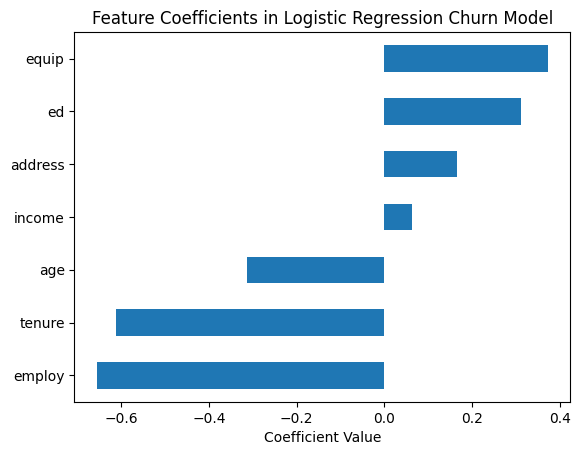

In [ ]:
coefficients = pd.Series(LR.coef_[0], index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

Large positive value of LR Coefficient for a given field indicates that increase in this parameter will lead to better chance of a positive, i.e. 1 class. A large negative value indicates the opposite, which means that an increase in this parameter will lead to poorer chance of a positive class. A lower absolute value indicates weaker affect of the change in that field on the predicted class. Let us examine this with the following exercises.  


## Performance Evaluation


Once the predictions have been generated, it becomes prudent to evaluate the performance of the model in predicting the target variable. Let us evaluate the log-loss value.

### log loss

Log loss (Logarithmic loss), also known as Binary Cross entropy loss, is a function that generates a loss value based on the class wise prediction probabilities and the actual class labels. The lower the log loss value, the better the model is considered to be.


In [ ]:
log_loss(y_test, yhat_prob)

0.40689596570478664

In [ ]:
X_norm = StandardScaler().fit(X).transform(X)
X_norm[0:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])